In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor, AdaBoostRegressor,
                              BaggingClassifier, RandomForestClassifier, AdaBoostClassifier)
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Nastavitve za lepe grafe
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Knjižnice uspešno naložene!")


Knjižnice uspešno naložene!


In [2]:
print("="*70)
print("REGRESIJSKI PROBLEM - Bike Rental Prediction")
print("="*70)

# Nalaganje podatkov
df_bike = pd.read_csv('bike_data.csv')

# Obdelava manjkajočih vrednosti za številčne s povprečjem
numeric_columns = df_bike.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df_bike[col].isnull().sum() > 0:
        df_bike[col].fillna(df_bike[col].mean(), inplace=True)

# Pretvorba datuma
df_bike[['day', 'month', 'year']] = df_bike['date'].str.split('/', expand=True)
df_bike['day'] = df_bike['day'].astype(int)
df_bike['month'] = df_bike['month'].astype(int)
df_bike['year'] = df_bike['year'].astype(int)
df_bike.drop('date', axis=1, inplace=True)

# One-hot encoding - POPRAVLJEN STOLPEC 'work_hours' namesto 'workhours'
df_bike = pd.get_dummies(df_bike, columns=['seasons', 'holiday', 'work_hours'], drop_first=False)

# Priprava X in y
X_bike = df_bike.drop('rented_bike_count', axis=1)
y_bike = df_bike['rented_bike_count']

print(f"Število primerov: {len(df_bike)}")
print(f"Število značilk: {X_bike.shape[1]}")
print(f"Ciljne vrednosti: {y_bike.name}")
print(f"\nStolpci: {list(X_bike.columns)}")


REGRESIJSKI PROBLEM - Bike Rental Prediction
Število primerov: 8760
Število značilk: 20
Ciljne vrednosti: rented_bike_count

Stolpci: ['hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'day', 'month', 'year', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'holiday_Holiday', 'holiday_No Holiday', 'work_hours_No', 'work_hours_Yes']


C:\Users\Lovro\AppData\Local\Temp\ipykernel_26992\898800121.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bike[col].fillna(df_bike[col].mean(), inplace=True)


KLASIFIKACIJSKI PROBLEM - Shapes Classification
Število slik: 300
Razredi: {'circles', 'squares', 'triangles'}
Število primerov: 300
Število značilk: 784
Število razredov: 3
Porazdelitev razredov:
  Razred 0 (circles): 100 slik
  Razred 1 (squares): 100 slik
  Razred 2 (triangles): 100 slik


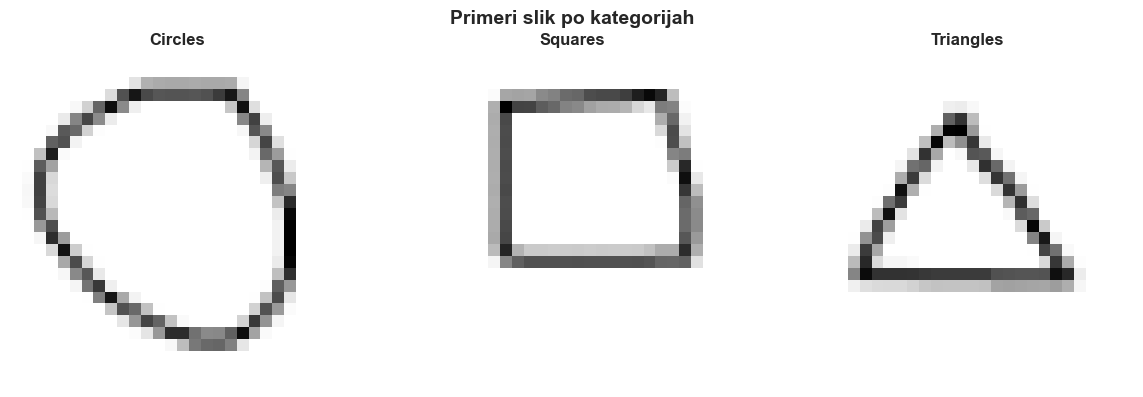


✓ Podatki shapes uspešno naloženi!


In [3]:
print("="*70)
print("KLASIFIKACIJSKI PROBLEM - Shapes Classification")
print("="*70)

import os
from PIL import Image

# Pot do podatkov
shapes_dir = 'shapes'

# 1. Izgradnja seznama poti do slik
image_paths = []
labels = []

# Preberi vse slike iz map
for category in ['circles', 'squares', 'triangles']:
    category_path = os.path.join(shapes_dir, category)

    for img_name in os.listdir(category_path):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(category_path, img_name))
            labels.append(category)

print(f"Število slik: {len(image_paths)}")
print(f"Razredi: {set(labels)}")

# 2. Nalaganje in pretvorba slik v enodimenzionalna polja
X_shapes = []
y_shapes = []

for img_path, label in zip(image_paths, labels):
    # Naloži sliko in pretvori v grayscale (PIL - Image, convert 'L')
    img = Image.open(img_path).convert('L')

    # Pretvori sliko v numpy array in nato v enodimenzionalno polje
    img_array = np.array(img).flatten()

    X_shapes.append(img_array)
    y_shapes.append(label)

# Pretvori v numpy arrays
X_shapes = np.array(X_shapes)
y_shapes = np.array(y_shapes)

# 3. Pretvorba oznak v numerične vrednosti (circles=0, squares=1, triangles=2)
label_mapping = {'circles': 0, 'squares': 1, 'triangles': 2}
y_shapes_numeric = np.array([label_mapping[label] for label in y_shapes])

# Pretvorba v DataFrame za konsistentnost s kodo
X_shapes_df = pd.DataFrame(X_shapes)
y_shapes_df = pd.Series(y_shapes_numeric)

print(f"Število primerov: {len(X_shapes)}")
print(f"Število značilk: {X_shapes.shape[1]}")
print(f"Število razredov: {len(np.unique(y_shapes_numeric))}")
print(f"Porazdelitev razredov:")
for label, count in zip(*np.unique(y_shapes_numeric, return_counts=True)):
    print(f"  Razred {label} ({list(label_mapping.keys())[label]}): {count} slik")

# 4. OPCIJSKO: Izris primera slike za vsak razred
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Primeri slik po kategorijah', fontsize=14, fontweight='bold')

for idx, (category, label) in enumerate(label_mapping.items()):
    # Najdi prvi primerek te kategorije
    sample_idx = np.where(y_shapes_numeric == label)[0][0]

    # Rekonstruiraj 2D sliko
    img_size = int(np.sqrt(X_shapes.shape[1]))
    img = X_shapes[sample_idx].reshape(img_size, img_size)

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{category.capitalize()}', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('shapes_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Podatki shapes uspešno naloženi!")


In [4]:
def manual_cross_validation(X, y, models_dict, problem_type='regression', n_splits=5):
    """
    Izvede ročno 5-kratno prečno validacijo BREZ cross_val_score

    Parameters:
    -----------
    X : array-like
        Značilke
    y : array-like
        Ciljne vrednosti
    models_dict : dict
        Slovar modelov {'ime_modela': model_objekt}
    problem_type : str
        'regression' ali 'classification'
    n_splits : int
        Število foldov (privzeto 5)

    Returns:
    --------
    results_df : DataFrame
        Rezultati po foldih in povprečja
    """

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=1234)
    results = []

    for model_name, model in models_dict.items():
        print(f"\nTreniranje modela: {model_name}")
        fold_num = 1

        for train_idx, test_idx in kf.split(X): #indexi vrstic
            print(f"  Fold {fold_num}/{n_splits}", end="")

            # Razdelitev podatkov
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Treniranje modela
            model.fit(X_train, y_train)

            # Napoved
            y_pred = model.predict(X_test)

            # Izračun metrik
            if problem_type == 'regression':
                mae = mean_absolute_error(y_test, y_pred)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                # Izračun MAPE (brez ničelnih vrednosti)
                mask = y_test != 0
                if mask.sum() > 0:
                    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
                else:
                    mape = 0.0

                results.append({
                    'model': model_name,
                    'fold': fold_num,
                    'MAE': mae,
                    'MAPE': mape,
                    'MSE': mse,
                    'R2': r2
                })
                print(f" - MAE: {mae:.2f}, R2: {r2:.4f}")

            else:  # classification
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='weighted')
                prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
                rec = recall_score(y_test, y_pred, average='weighted')

                results.append({
                    'model': model_name,
                    'fold': fold_num,
                    'Accuracy': acc,
                    'F1': f1,
                    'Precision': prec,
                    'Recall': rec
                })
                print(f" - Accuracy: {acc:.4f}, F1: {f1:.4f}")

            fold_num += 1

    return pd.DataFrame(results)

print("Funkcija manual_cross_validation definirana!")


Funkcija manual_cross_validation definirana!


In [5]:
# REGRESIJSKI MODELI
regression_models = {
    'Bagging': BaggingRegressor(n_estimators=50, random_state=1234),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=1234),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, random_state=1234),
    'XGBoost': XGBRegressor(n_estimators=50, random_state=1234, verbosity=0)
}

# KLASIFIKACIJSKI MODELI
classification_models = {
    'Bagging': BaggingClassifier(n_estimators=50, random_state=1234),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=1234),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=1234),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=1234, eval_metric='mlogloss',
                             use_label_encoder=False, verbosity=0)
}

print("Modeli definirani:")
print(f"  Regresijski: {list(regression_models.keys())}")
print(f"  Klasifikacijski: {list(classification_models.keys())}")


Modeli definirani:
  Regresijski: ['Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']
  Klasifikacijski: ['Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']


In [6]:
print("="*70)
print("IZVAJANJE 5-FOLD CROSS-VALIDATION - REGRESIJA")
print("="*70)

results_reg = manual_cross_validation(
    X_bike,
    y_bike,
    regression_models,
    problem_type='regression',
    n_splits=5
)

# Izpis rezultatov po foldih
print("\n" + "-"*70)
print("REZULTATI PO FOLDIH - REGRESIJA")
print("-"*70)
print(results_reg.to_string(index=False))

# Povprečja po modelih
avg_reg = results_reg.groupby('model').mean().drop('fold', axis=1)
print("\n" + "="*70)
print("POVPREČNI REZULTATI - REGRESIJA")
print("="*70)
print(avg_reg.round(4))


IZVAJANJE 5-FOLD CROSS-VALIDATION - REGRESIJA

Treniranje modela: Bagging
  Fold 1/5 - MAE: 133.82, R2: 0.8889
  Fold 2/5 - MAE: 126.31, R2: 0.8930
  Fold 3/5 - MAE: 132.36, R2: 0.8698
  Fold 4/5 - MAE: 145.24, R2: 0.8561
  Fold 5/5 - MAE: 128.38, R2: 0.8931

Treniranje modela: Random Forest
  Fold 1/5 - MAE: 133.79, R2: 0.8903
  Fold 2/5 - MAE: 126.44, R2: 0.8923
  Fold 3/5 - MAE: 132.08, R2: 0.8713
  Fold 4/5 - MAE: 144.78, R2: 0.8558
  Fold 5/5 - MAE: 128.29, R2: 0.8932

Treniranje modela: AdaBoost
  Fold 1/5 - MAE: 364.26, R2: 0.5951
  Fold 2/5 - MAE: 380.72, R2: 0.5468
  Fold 3/5 - MAE: 355.98, R2: 0.5647
  Fold 4/5 - MAE: 359.72, R2: 0.5405
  Fold 5/5 - MAE: 361.69, R2: 0.5822

Treniranje modela: XGBoost
  Fold 1/5 - MAE: 132.47, R2: 0.8963
  Fold 2/5 - MAE: 129.94, R2: 0.8969
  Fold 3/5 - MAE: 133.41, R2: 0.8815
  Fold 4/5 - MAE: 144.08, R2: 0.8664
  Fold 5/5 - MAE: 127.70, R2: 0.8997

----------------------------------------------------------------------
REZULTATI PO FOLDIH - R

C:\Users\Lovro\AppData\Local\Temp\ipykernel_26992\240246992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_reg, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\AppData\Local\Temp\ipykernel_26992\240246992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_reg, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\AppData\Local\Temp\ipykernel_26992\240246992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_reg, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\AppData\Lo

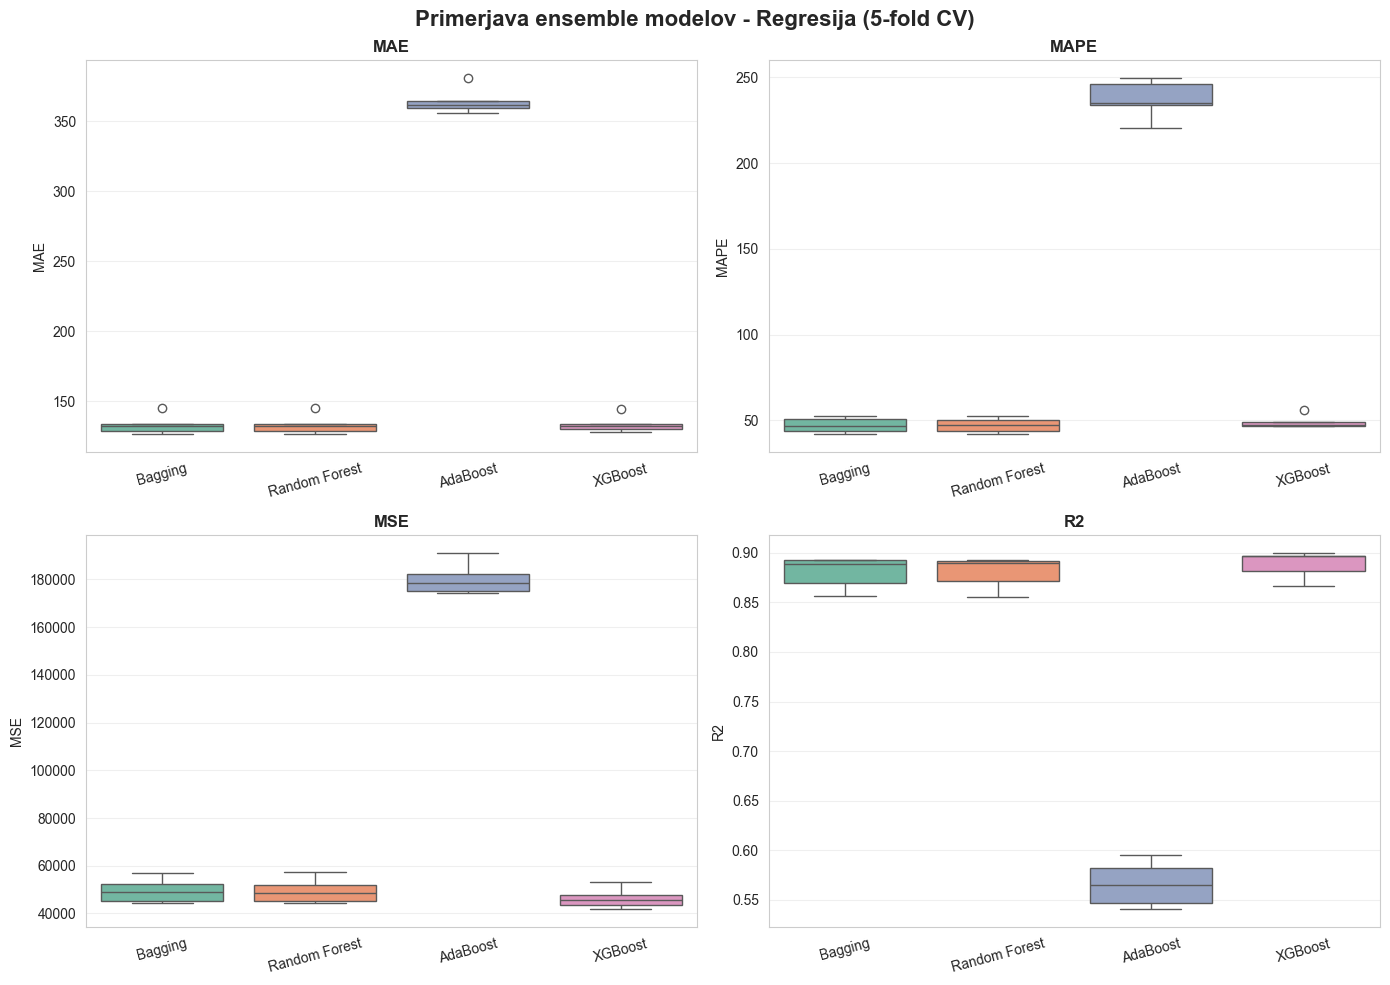

In [7]:
# Boxploti za vsako metriko
metrics_reg = ['MAE', 'MAPE', 'MSE', 'R2']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Primerjava ensemble modelov - Regresija (5-fold CV)', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_reg):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=results_reg, x='model', y=metric, ax=ax, palette='Set2')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('regresija_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


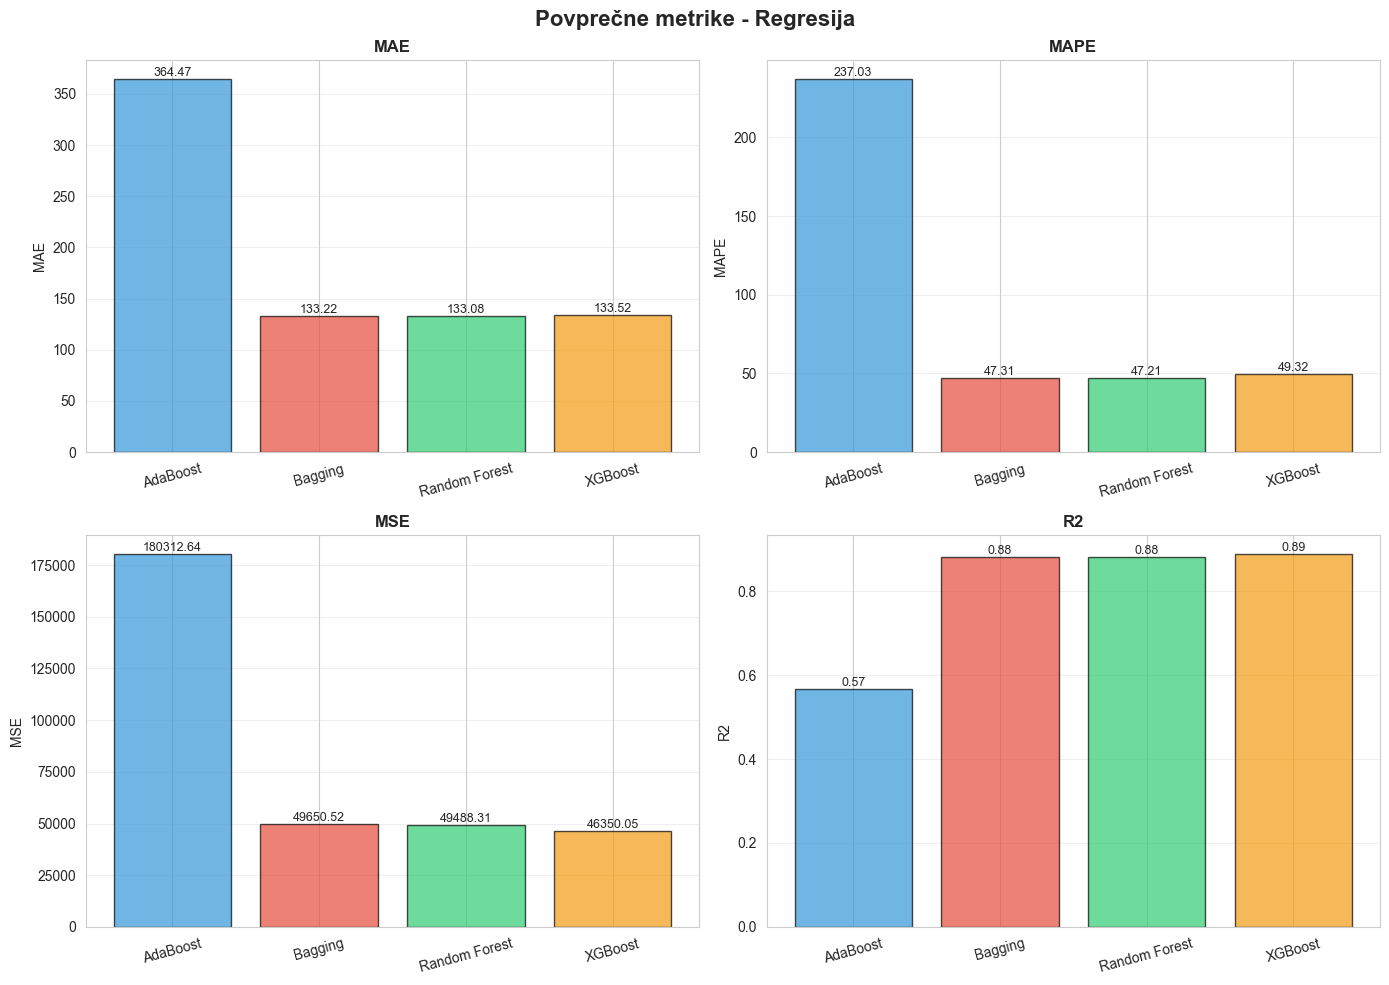

In [8]:
# Stolpični graf povprečnih vrednosti
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Povprečne metrike - Regresija', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics_reg):
    ax = axes[idx // 2, idx % 2]
    values = avg_reg[metric]
    bars = ax.bar(values.index, values.values, color=colors, alpha=0.7, edgecolor='black')

    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

    # Dodaj vrednosti na stolpce
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('regresija_povprecja.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
print("="*70)
print("IZVAJANJE 5-FOLD CROSS-VALIDATION - KLASIFIKACIJA")
print("="*70)

results_class = manual_cross_validation(
    X_shapes_df,
    y_shapes_df,
    classification_models,
    problem_type='classification',
    n_splits=5
)

# Izpis rezultatov po foldih
print("\n" + "-"*70)
print("REZULTATI PO FOLDIH - KLASIFIKACIJA")
print("-"*70)
print(results_class.to_string(index=False))

# Povprečja po modelih
avg_class = results_class.groupby('model').mean().drop('fold', axis=1)
print("\n" + "="*70)
print("POVPREČNI REZULTATI - KLASIFIKACIJA")
print("="*70)
print(avg_class.round(4))


IZVAJANJE 5-FOLD CROSS-VALIDATION - KLASIFIKACIJA

Treniranje modela: Bagging
  Fold 1/5 - Accuracy: 0.5667, F1: 0.5655
  Fold 2/5 - Accuracy: 0.5333, F1: 0.5340
  Fold 3/5 - Accuracy: 0.6167, F1: 0.6175
  Fold 4/5 - Accuracy: 0.4833, F1: 0.4581
  Fold 5/5 - Accuracy: 0.4000, F1: 0.3977

Treniranje modela: Random Forest
  Fold 1/5 - Accuracy: 0.6000, F1: 0.5920
  Fold 2/5 - Accuracy: 0.5500, F1: 0.5511
  Fold 3/5 - Accuracy: 0.6167, F1: 0.6215
  Fold 4/5 - Accuracy: 0.5000, F1: 0.4878
  Fold 5/5 - Accuracy: 0.4667, F1: 0.4670

Treniranje modela: AdaBoost
  Fold 1/5 - Accuracy: 0.4667, F1: 0.4708
  Fold 2/5 - Accuracy: 0.3833, F1: 0.3763
  Fold 3/5 - Accuracy: 0.5167, F1: 0.5196
  Fold 4/5 - Accuracy: 0.4833, F1: 0.4692
  Fold 5/5 - Accuracy: 0.4500, F1: 0.4511

Treniranje modela: XGBoost
  Fold 1/5 - Accuracy: 0.5333, F1: 0.5155
  Fold 2/5 - Accuracy: 0.4667, F1: 0.4694
  Fold 3/5 - Accuracy: 0.5500, F1: 0.5632
  Fold 4/5 - Accuracy: 0.4833, F1: 0.4758
  Fold 5/5 - Accuracy: 0.4500, F1

C:\Users\Lovro\AppData\Local\Temp\ipykernel_28548\3135669549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_class, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\AppData\Local\Temp\ipykernel_28548\3135669549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_class, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\AppData\Local\Temp\ipykernel_28548\3135669549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_class, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Lovro\A

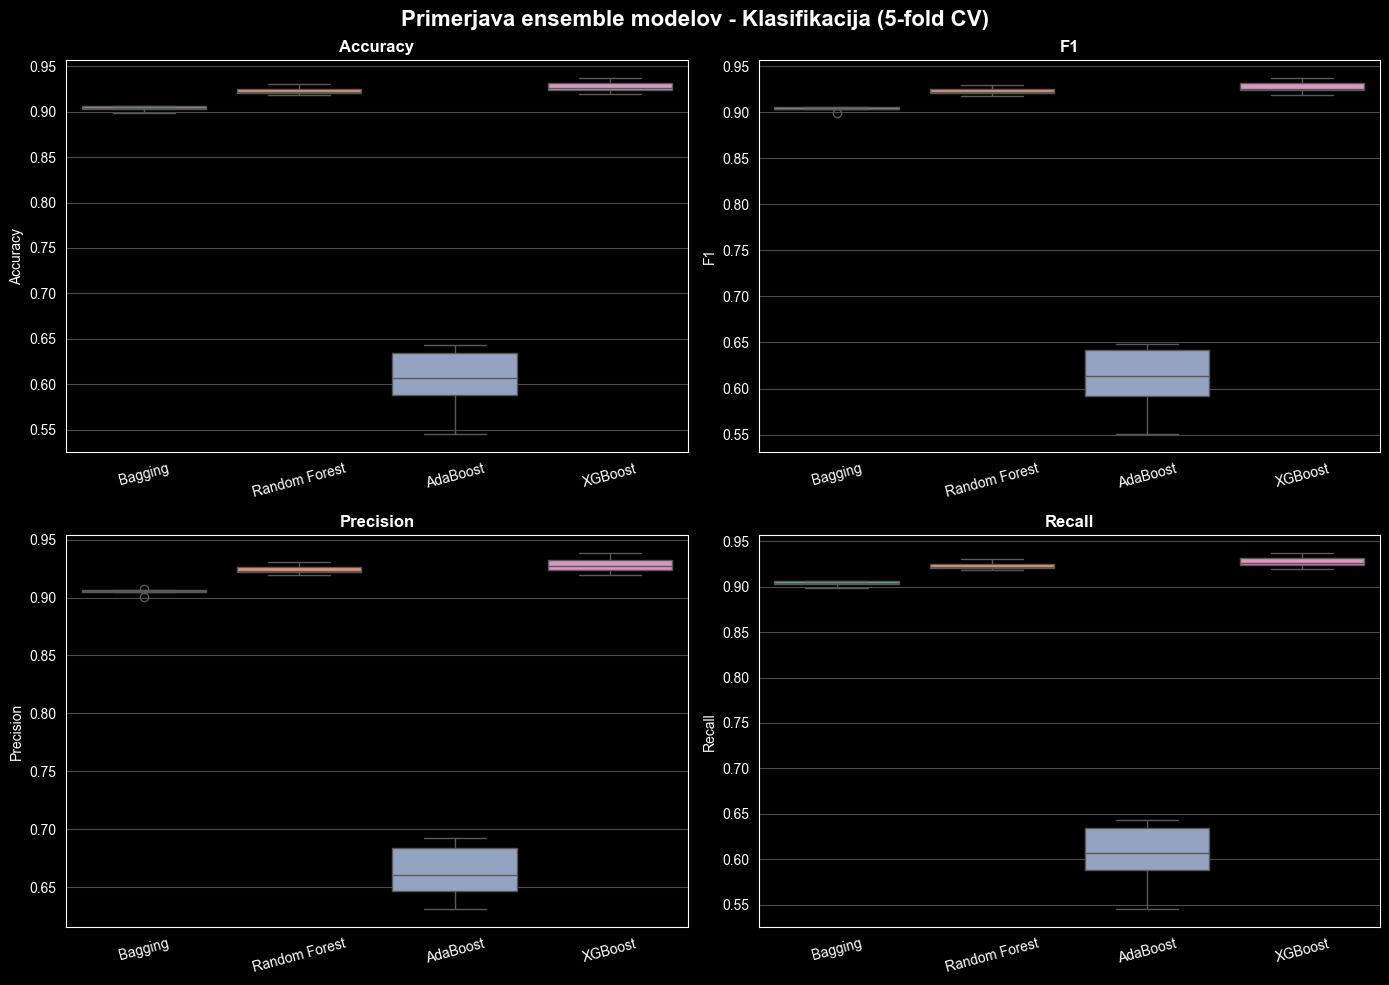

In [16]:
# Boxploti za vsako metriko
metrics_class = ['Accuracy', 'F1', 'Precision', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Primerjava ensemble modelov - Klasifikacija (5-fold CV)', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_class):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=results_class, x='model', y=metric, ax=ax, palette='Set2')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('klasifikacija_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


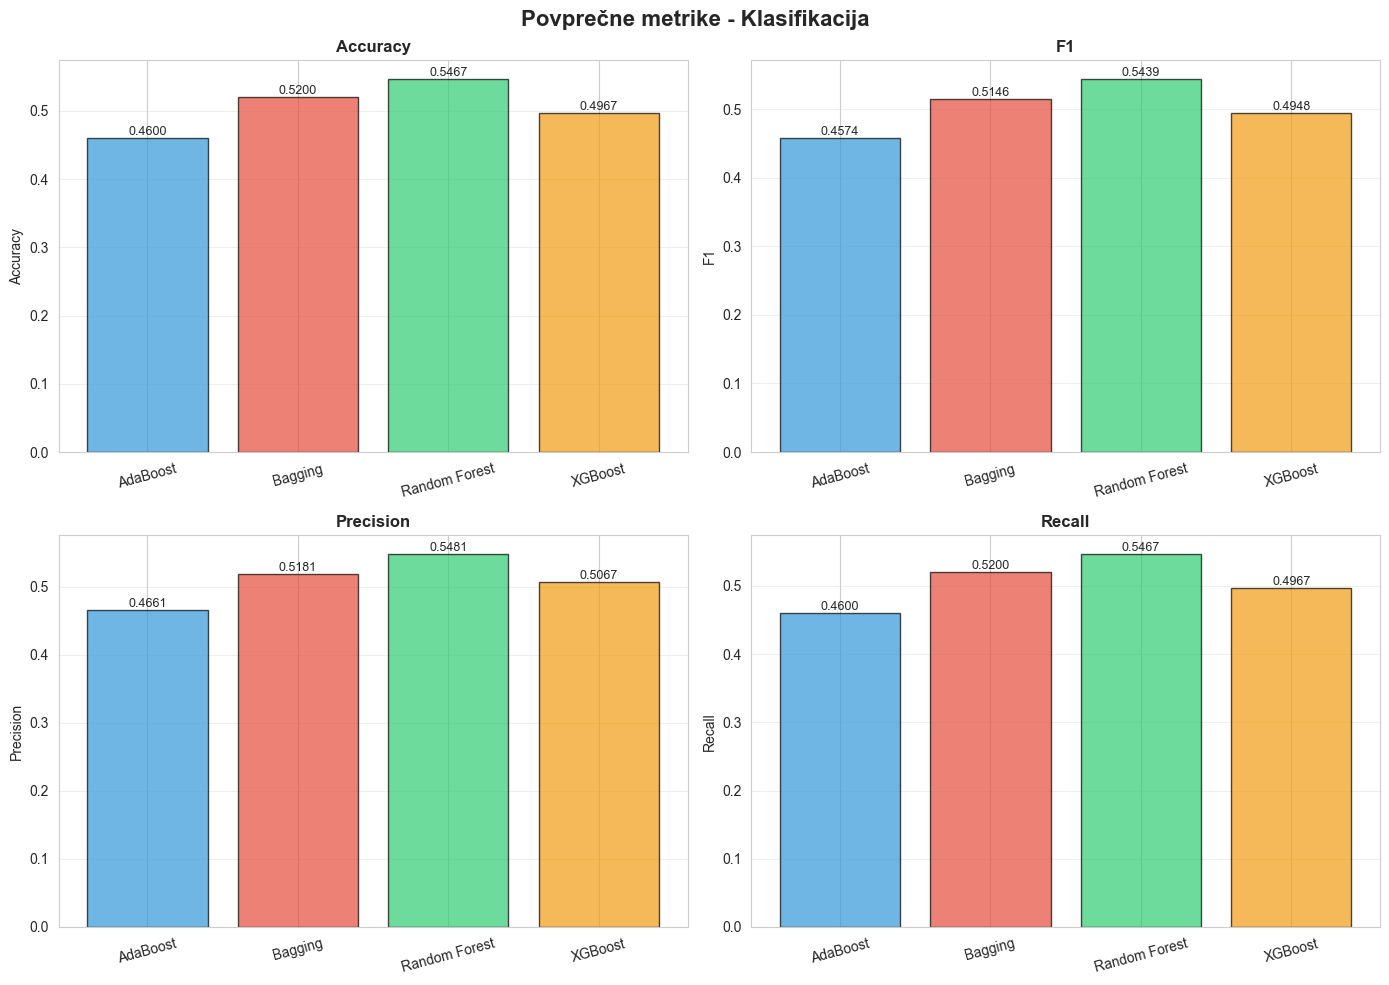

In [11]:
# Stolpični graf povprečnih vrednosti
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Povprečne metrike - Klasifikacija', fontsize=16, fontweight='bold')

metrics_class = ['Accuracy', 'F1', 'Precision', 'Recall']

for idx, metric in enumerate(metrics_class):
    ax = axes[idx // 2, idx % 2]
    values = avg_class[metric]
    bars = ax.bar(values.index, values.values, color=colors, alpha=0.7, edgecolor='black')

    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

    # Dodaj vrednosti na stolpce
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('klasifikacija_povprecja.png', dpi=300, bbox_inches='tight')
plt.show()
